[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter15_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 15: Review and exam preparation

*Lecture notebook: the course in one notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Part 1: the Box–Jenkins method from start to finish on the monthly HICP of Romania (Eurostat), 2005–2026: plot, unit-root tests, identification, estimation, residual checks, forecasts and their evaluation (Chapters 0–4).
- Part 2: the output of exam problem 3 (an AR(1) × SAR(1) model) and its forecast computed by hand.
- Part 3: one short computation per block of chapters on Romanian data: exponential smoothing (Chapter 0), GARCH (Chapter 5), VAR and Granger causality (Chapters 6–7), long memory (Chapter 8), the local level model (Chapter 10).
- Chapters 11–14 are for self-study.
- The first code cell installs the `arch` package if it is missing (`pip install arch`).
- References: Box, Jenkins and Reinsel (2008); Huang and Petukhina (2022); Hyndman and Athanasopoulos (2021).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- $y_t = 100\ln P_t$; monthly inflation $100\Delta\ln P_t$; annual inflation $100\Delta_{12}\ln P_t$; $z_t = \Delta\Delta_{12}\,100\ln P_t$.
- `adf_kpss(x, reg)`: ADF ($H_0$: unit root) and KPSS ($H_0$: stationarity) with the same deterministic terms.
- `ljung_box(e, lags, df_adj)`: Ljung–Box with $m - k$ degrees of freedom for the residuals of a model with $k$ ARMA parameters.
- `dm_test(e1, e2)`: Diebold–Mariano on squared errors with the Harvey–Leybourne–Newbold correction.

In [6]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
START = '2005-01-01'
TRAIN_END = '2024-08-01'
S = 12
MAXLAG = 36
IDENT = ((1, 1, 0), (0, 1, 1, 12))
H = 12


def hicp(start=START):
    """Romanian HICP (Eurostat, monthly, 2015 = 100) from `start`."""
    h = read_eurostat(*HICP).loc[start:].astype(float)
    h.index = pd.DatetimeIndex(h.index, freq='MS')
    return h.rename('hicp')


def transforms(h):
    """100 ln P and its differences: monthly inflation d ln P, annual inflation d12 ln P, z = d d12 ln P."""
    y = 100 * np.log(h)
    return pd.DataFrame({'y': y, 'm': y.diff(), 'a': y.diff(S), 'z': y.diff().diff(S)})


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def adf_kpss(x, reg):
    """ADF (lags by AIC) and KPSS (automatic bandwidth) with the same deterministic terms ('c' or 'ct')."""
    a = adfuller(x, regression=reg, autolag='AIC')
    k = kpss(x, regression=reg, nlags='auto')
    return {'reg': reg, 'n': int(len(x)), 'adf': float(a[0]), 'adf_p': float(a[1]), 'adf_lags': int(a[2]),
            'adf_cv1': float(a[4]['1%']), 'adf_cv5': float(a[4]['5%']), 'adf_cv10': float(a[4]['10%']),
            'kpss': float(k[0]), 'kpss_p': float(k[1]), 'kpss_cv5': float(k[3]['5%'])}


def ljung_box(e, lags, df_adj=0):
    """Ljung-Box Q(m) for each m in `lags`, with m - df_adj degrees of freedom."""
    e = np.asarray(e, float)
    T = len(e)
    r = acf(e, nlags=max(lags), fft=False)
    out = {}
    for m in lags:
        q = T * (T + 2) * np.sum(r[1:m + 1] ** 2 / (T - np.arange(1, m + 1)))
        out[str(m)] = {'q': float(q), 'df': int(m - df_adj), 'p': float(stats.chi2.sf(q, m - df_adj))}
    return out


def dm_test(e1, e2, h=1):
    """Diebold-Mariano test on squared errors, HLN correction, t(n - 1) p-value; a negative mean favours e1."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def fit_sarima(y, order, sorder):
    return SARIMAX(y, order=order, seasonal_order=sorder, trend='n').fit(disp=False)


def label(order, sorder):
    return f'({order[0]},{order[1]},{order[2]})({sorder[0]},{sorder[1]},{sorder[2]})'


def model_summary(m, k):
    """Estimates, standard errors and residual checks of a fitted SARIMAX model with k ARMA parameters."""
    e = m.resid[S + 1:]
    zs = e / np.sqrt(m.params['sigma2'])
    lb = ljung_box(e, [12, 24], df_adj=k)
    jb = stats.jarque_bera(e)
    big = zs.abs().sort_values(ascending=False).head(3)
    return {'params': {k_: float(v) for k_, v in m.params.items()}, 'se': {k_: float(v) for k_, v in m.bse.items()},
            'z': {k_: float(v) for k_, v in m.tvalues.items()}, 'p': {k_: float(v) for k_, v in m.pvalues.items()},
            'loglik': float(m.llf), 'aicc': float(m.aicc), 'bic': float(m.bic), 'lb': lb, 'jb': float(jb[0]),
            'jb_p': float(jb[1]), 'skew': float(stats.skew(e)), 'kurt': float(stats.kurtosis(e, fisher=False)),
            'big': [[str(i.date()), float(zs.loc[i])] for i in big.index], 'n': int(m.nobs),
            'ar_roots': [float(abs(r)) for r in m.arroots], 'ma_roots': [float(abs(r)) for r in m.maroots]}

## 1. Step 1: plot the data

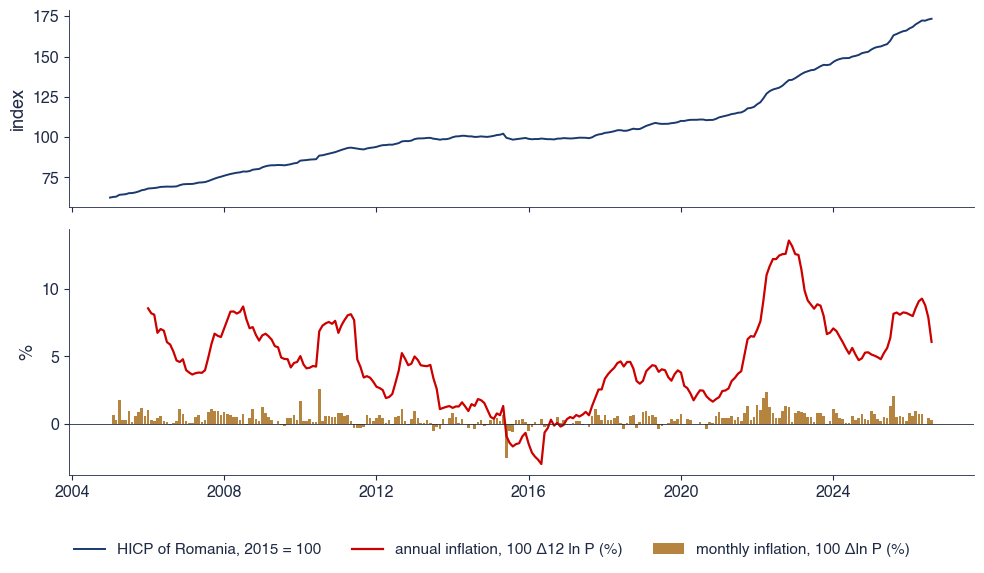

{'n': 260, 'first': '2005-01-01', 'last': '2026-08-01', 'last_index': 173.45, 'last_a': 6.085165825315414, 'last_m': 0.25977789179796673, 'max_a': 13.620449887410246, 'max_a_d': '2022-11-01', 'min_a': -3.0004237637526785, 'min_a_d': '2016-05-01', 'mean_m': 0.3939779412596458, 'mean_a': 4.632983364990187, 'a_2024_08': 5.143328178891295, 'a_2025_07': 6.379648032463024, 'a_2025_08': 8.173930364686498, 'm_2025_08': 2.0739282964731274, 'm_by_month': {1: 0.7441329745047098, 2: 0.48342072148337095, 3: 0.4530637939937854, 4: 0.5238657720830546, 5: 0.3942195847451728, 6: -0.029556707327445378, 7: 0.2922072030333451, 8: 0.16511222774218998, 9: 0.38712481340842314, 10: 0.6201056216287546, 11: 0.3835272838580836, 12: 0.3331554818224975}}


In [7]:
def fig_bj_data(save_it=True):
    """Step 1: plot the data -- the index and the two inflation rates."""
    h = hicp()
    d = transforms(h)
    fig, ax = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, gridspec_kw={'height_ratios': [1, 1.25]})
    ax[0].plot(h.index, h, color=st.MainBlue, label='HICP of Romania, 2015 = 100')
    ax[0].set_ylabel('index')
    ax[1].bar(d.index, d['m'], width=25, color=st.Amber, label='monthly inflation, 100 Δln P (%)')
    ax[1].plot(d.index, d['a'], color=st.IDAred, lw=1.6, label='annual inflation, 100 Δ12 ln P (%)')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_ylabel('%')
    st.fig_legend_bottom(fig, ncol=3, y=0.04)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch15_bj_data', save_it)
    a = d['a'].dropna()
    m = d['m'].dropna()
    return {'n': int(len(h)), 'first': str(h.index[0].date()), 'last': str(h.index[-1].date()),
            'last_index': float(h.iloc[-1]), 'last_a': float(a.iloc[-1]), 'last_m': float(m.iloc[-1]),
            'max_a': float(a.max()), 'max_a_d': str(a.idxmax().date()), 'min_a': float(a.min()),
            'min_a_d': str(a.idxmin().date()), 'mean_m': float(m.mean()), 'mean_a': float(a.mean()),
            'a_2024_08': float(a.loc[TRAIN_END]), 'a_2025_07': float(a.loc['2025-07-01']),
            'a_2025_08': float(a.loc['2025-08-01']), 'm_2025_08': float(m.loc['2025-08-01']),
            'm_by_month': {int(k): float(v) for k, v in m.groupby(m.index.month).mean().items()}}


print(fig_bj_data(save_it=False))

- The index trends up; monthly inflation is seasonal (high in January, low in June); tax changes move prices in a single month.

## 2. Step 2: unit-root and stationarity tests

In [8]:
def bj_tests():
    """Step 2: unit-root (ADF) and stationarity (KPSS) tests on four transformations."""
    d = transforms(hicp())
    return {'y': adf_kpss(d['y'].dropna(), 'ct'), 'm': adf_kpss(d['m'].dropna(), 'c'),
            'a': adf_kpss(d['a'].dropna(), 'c'), 'z': adf_kpss(d['z'].dropna(), 'c')}


pd.DataFrame(bj_tests()).T[['reg', 'n', 'adf', 'adf_p', 'adf_cv5', 'kpss', 'kpss_cv5']].round(3)

/var/folders/lj/nd_qpcpd33l0sg_q9hgd9tt00000gn/T/ipykernel_51904/1481410462.py:38: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k = kpss(x, regression=reg, nlags='auto')
/var/folders/lj/nd_qpcpd33l0sg_q9hgd9tt00000gn/T/ipykernel_51904/1481410462.py:38: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k = kpss(x, regression=reg, nlags='auto')


,reg,n,adf,adf_p,adf_cv5,kpss,kpss_cv5
y,ct,260,-0.961364,0.949096,-3.427987,0.314494,0.146
m,c,259,-3.996413,0.001429,-2.873033,0.43064,0.463
a,c,248,-1.692915,0.434766,-2.87408,0.424191,0.463
z,c,247,-4.830814,0.000047,-2.87408,0.11327,0.463


- The level has a unit root; annual inflation is inconclusive; $z_t$ is stationary by both tests: $d = D = 1$.

## 3. Step 3: identification

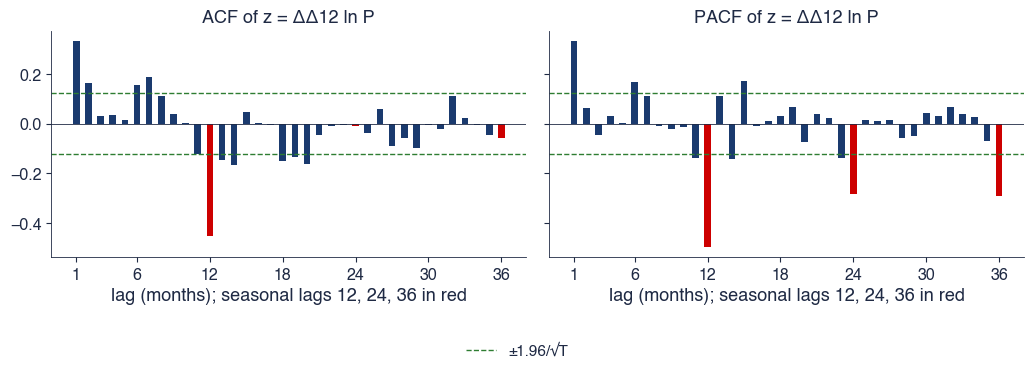

lags outside the band, ACF: [1, 2, 6, 7, 12, 13, 14, 18, 19, 20]
lags outside the band, PACF: [1, 6, 11, 12, 14, 15, 23, 24, 36]


In [9]:
def fig_bj_acf(save_it=True):
    """Step 3: identification from the ACF and PACF of z = d d12 ln P."""
    z = transforms(hicp())['z'].dropna()
    r = acf(z, nlags=MAXLAG, fft=False)[1:]
    p = pacf(z, nlags=MAXLAG)[1:]
    band = 1.96 / np.sqrt(len(z))
    lags = np.arange(1, MAXLAG + 1)
    fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
    for a, v, nm in ((ax[0], r, 'ACF'), (ax[1], p, 'PACF')):
        col = [st.IDAred if k % S == 0 else st.MainBlue for k in lags]
        a.bar(lags, v, width=0.55, color=col)
        a.axhline(band, color=st.Forest, ls='--', lw=1, label='±1.96/√T')
        a.axhline(-band, color=st.Forest, ls='--', lw=1)
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(f'{nm} of z = ΔΔ12 ln P')
        a.set_xlabel('lag (months); seasonal lags 12, 24, 36 in red')
        a.set_xticks([1, 6, 12, 18, 24, 30, 36])
    st.fig_legend_bottom(fig, ncol=1, y=0.06)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch15_bj_acf', save_it)
    out = {'n': int(len(z)), 'band': float(band), 'r': [float(x) for x in r], 'p': [float(x) for x in p]}
    out['out_r'] = [int(k) for k, v in zip(lags, r) if abs(v) > band]
    out['out_p'] = [int(k) for k, v in zip(lags, p) if abs(v) > band]
    return out


ac = fig_bj_acf(save_it=False)
print('lags outside the band, ACF:', ac['out_r'])
print('lags outside the band, PACF:', ac['out_p'])

- One regular spike and one seasonal spike at lag 12 in the ACF, a decaying seasonal PACF: SARIMA$(1,1,0)(0,1,1)_{12}$.

## 4. Step 4: estimation of every small SARIMA model (about a minute)

In [10]:
def bj_grid(pmax=2, qmax=2):
    """Step 4: every SARIMA(p,1,q)(P,1,Q)12 with p, q <= 2 and P, Q <= 1 on the training sample."""
    y = transforms(hicp())['y'].loc[:TRAIN_END]
    rows = []
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            for P in (0, 1):
                for Q in (0, 1):
                    o, so = (p, 1, q), (P, 1, Q, S)
                    try:
                        m = fit_sarima(y, o, so)
                    except Exception:            # noqa: BLE001  (a model that fails to converge is skipped)
                        continue
                    k = p + q + P + Q
                    e = m.resid[S + 1:]
                    lb = ljung_box(e, [12, 24], df_adj=k)
                    rows.append({'model': label(o, so), 'order': list(o), 'sorder': list(so), 'k': k + 1,
                                 'loglik': float(m.llf), 'aicc': float(m.aicc), 'bic': float(m.bic),
                                 'lb12_p': lb['12']['p'], 'lb24_p': lb['24']['p'],
                                 'converged': bool(m.mle_retvals.get('converged', True))})
    rows.sort(key=lambda r: r['bic'])
    ok = [r for r in rows if r['lb24_p'] > 0.05 and r['lb12_p'] > 0.05 and r['converged']]
    ident = next(r for r in rows if r['model'] == label(*IDENT))
    return {'n_train': int(len(y)), 'train_first': str(y.index[0].date()), 'train_last': str(y.index[-1].date()),
            'n_models': len(rows), 'rows': rows, 'best_bic': rows[0]['model'],
            'best_aicc': min(rows, key=lambda r: r['aicc'])['model'], 'chosen': ok[0]['model'],
            'chosen_order': ok[0]['order'], 'chosen_sorder': ok[0]['sorder'], 'ident': ident}


grid = bj_grid()
print('lowest BIC:', grid['best_bic'], '| chosen:', grid['chosen'])
pd.DataFrame(grid['rows'])[['model', 'k', 'aicc', 'bic', 'lb12_p', 'lb24_p']].head(10).round(3)

lowest BIC: (1,1,1)(0,1,1) | chosen: (2,1,1)(0,1,1)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,k,aicc,bic,lb12_p,lb24_p
0,"(1,1,1)(0,1,1)",4,285.430,298.875,0.029,0.088
1,"(2,1,1)(0,1,1)",5,282.617,299.376,0.233,0.237
2,"(1,1,2)(0,1,1)",5,282.810,299.569,0.233,0.217
3,"(1,1,1)(1,1,1)",5,287.741,304.500,0.017,0.070
4,"(2,1,1)(1,1,1)",6,284.826,304.880,0.152,0.185
5,"(1,1,2)(1,1,1)",6,284.867,304.921,0.154,0.176
6,"(1,1,0)(0,1,1)",3,295.172,305.284,0.004,0.004
7,"(2,1,0)(0,1,1)",4,293.499,306.945,0.020,0.037
8,"(2,1,2)(0,1,1)",6,288.224,308.278,0.020,0.086
9,"(1,1,0)(1,1,1)",4,296.889,310.334,0.004,0.004


- The identified model fails the Ljung–Box test; the chosen model has the lowest BIC among the models whose residuals pass at lags 12 and 24.

## 5. Step 5: residual diagnostics

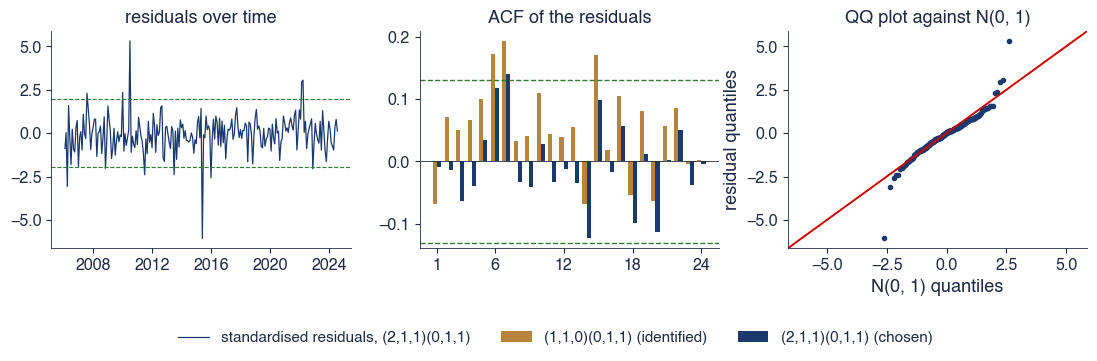

          estimate      se       p
ar.L1       1.1562  0.1491  0.0000
ar.L2      -0.1831  0.1218  0.1329
ma.L1      -0.8559  0.0994  0.0000
ma.S.L12   -0.9352  0.0980  0.0000
sigma2      0.1791  0.0139  0.0000
Ljung-Box: {'12': {'q': 10.486132693575502, 'df': 8, 'p': 0.23254853351524482}, '24': {'q': 24.13365485298423, 'df': 20, 'p': 0.2366025921165887}}
Jarque-Bera: 450.4 | largest residuals: [['2015-06-01', -6.065084902605285], ['2010-07-01', 5.311307180997568], ['2006-04-01', -3.073598903944313]]


In [11]:
def fig_bj_diag(grid=None, save_it=True):
    """Step 5: diagnostics of the identified model and of the chosen model (training sample)."""
    grid = grid or bj_grid()
    y = transforms(hicp())['y'].loc[:TRAIN_END]
    o, so = tuple(grid['chosen_order']), tuple(grid['chosen_sorder'])
    m = fit_sarima(y, o, so)
    mi = fit_sarima(y, *IDENT)
    k = sum(o) - 1 + so[0] + so[2]
    out = {'chosen': model_summary(m, k), 'ident': model_summary(mi, 2), 'model': label(o, so)}
    e = m.resid[S + 1:]
    zs = e / np.sqrt(m.params['sigma2'])
    ei = mi.resid[S + 1:]
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
    ax[0].plot(zs.index, zs, color=st.MainBlue, lw=0.9, label=f'standardised residuals, {label(o, so)}')
    ax[0].axhline(1.96, color=st.Forest, ls='--', lw=0.8)
    ax[0].axhline(-1.96, color=st.Forest, ls='--', lw=0.8)
    ax[0].set_title('residuals over time')
    ax[0].set_xticks(pd.to_datetime(['2008-01-01', '2012-01-01', '2016-01-01', '2020-01-01', '2024-01-01']))
    ax[0].set_xticklabels(['2008', '2012', '2016', '2020', '2024'])
    lags = np.arange(1, 25)
    band = 1.96 / np.sqrt(len(e))
    ax[1].bar(lags - 0.18, acf(ei, nlags=24, fft=False)[1:], width=0.36, color=st.Amber, label=f'{label(*IDENT)} (identified)')
    ax[1].bar(lags + 0.18, acf(e, nlags=24, fft=False)[1:], width=0.36, color=st.MainBlue, label=f'{label(o, so)} (chosen)')
    ax[1].axhline(band, color=st.Forest, ls='--', lw=1)
    ax[1].axhline(-band, color=st.Forest, ls='--', lw=1)
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('ACF of the residuals')
    ax[1].set_xticks([1, 6, 12, 18, 24])
    sm.qqplot(zs, line='45', ax=ax[2], markersize=3, markerfacecolor=st.MainBlue, markeredgecolor=st.MainBlue)
    for ln in ax[2].get_lines()[1:]:
        ln.set_color(st.IDAred)
    ax[2].set_title('QQ plot against N(0, 1)')
    ax[2].set_xlabel('N(0, 1) quantiles')
    ax[2].set_ylabel('residual quantiles')
    st.fig_legend_bottom(fig, ncol=3, y=0.07)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch15_bj_diag', save_it)
    return out


d = fig_bj_diag(grid, save_it=False)
print(pd.DataFrame({'estimate': d['chosen']['params'], 'se': d['chosen']['se'], 'p': d['chosen']['p']}).round(4))
print('Ljung-Box:', d['chosen']['lb'])
print('Jarque-Bera:', round(d['chosen']['jb'], 1), '| largest residuals:', d['chosen']['big'])

- No autocorrelation left, but heavy tails: the two largest residuals are the tax changes of June 2015 and July 2010.

## 6. Step 6: forecasts and their evaluation

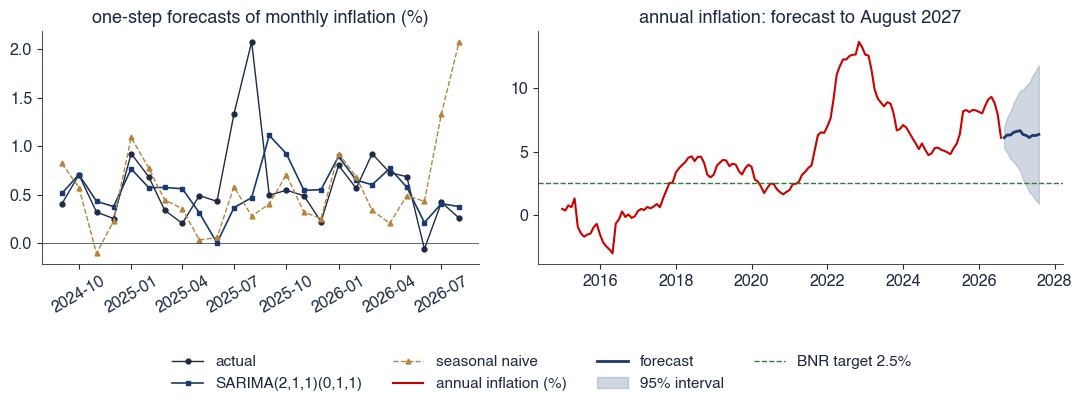

                 rmse    mae   mase
SARIMA          0.449  0.284  0.665
Seasonal naive  0.635  0.421  0.986
Naive           0.512  0.375  0.879
DM against seasonal naive: {'dbar': -0.20205404397353602, 'dm': -1.4343817045231284, 'hln': -1.4041808126126054, 'p': 0.17362516462173738, 'n': 24}
annual inflation forecasts: {'a1': 6.1, 'a1_lo': 5.26, 'a1_hi': 6.93, 'a12': 6.35, 'a12_lo': 0.9, 'a12_hi': 11.8}


In [12]:
def fig_bj_forecast(grid=None, save_it=True):
    """Step 6: one-step forecasts on the test sample against benchmarks; 12-month forecasts of annual inflation."""
    grid = grid or bj_grid()
    d = transforms(hicp())
    y = d['y']
    o, so = tuple(grid['chosen_order']), tuple(grid['chosen_sorder'])
    m = fit_sarima(y.loc[:TRAIN_END], o, so)
    mf = m.apply(y)                                           # the same parameters, filtered over the whole sample
    test = y.index[y.index > TRAIN_END]
    pred = mf.get_prediction(start=test[0], end=test[-1], dynamic=False).predicted_mean
    w = d['m']
    f_sar = (pred - y.shift(1).loc[test]).rename('SARIMA')    # forecast of monthly inflation
    f_sn = w.shift(S).loc[test].rename('Seasonal naive')
    f_nv = w.shift(1).loc[test].rename('Naive')
    act = w.loc[test]
    wt = w.loc[:TRAIN_END].dropna()
    scale = np.mean(np.abs(wt.values[S:] - wt.values[:-S]))
    acc = {}
    for f in (f_sar, f_sn, f_nv):
        e = act - f
        acc[f.name] = {'rmse': float(np.sqrt(np.mean(e ** 2))), 'mae': float(np.mean(np.abs(e))),
                       'mase': float(np.mean(np.abs(e)) / scale)}
    dm_sn = dm_test(act - f_sar, act - f_sn)
    dm_nv = dm_test(act - f_sar, act - f_nv)
    # 12-month forecasts of annual inflation from the full sample
    mfull = fit_sarima(y, o, so)
    fc = mfull.get_forecast(H)
    mean, se = fc.predicted_mean, fc.se_mean
    base = y.shift(S).reindex(mean.index)
    base.loc[:] = [y.loc[t - pd.DateOffset(months=S)] for t in mean.index]
    a_f = mean - base
    lo, hi = a_f - 1.96 * se, a_f + 1.96 * se
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1, 1.2]})
    ax[0].plot(act.index, act, 'o-', color=st.DarkText, ms=3.5, lw=1, label='actual')
    ax[0].plot(f_sar.index, f_sar, 's-', color=st.MainBlue, ms=3.5, lw=1.2, label=f'SARIMA{label(o, so)}')
    ax[0].plot(f_sn.index, f_sn, '^--', color=st.Amber, ms=3.5, lw=1, label='seasonal naive')
    ax[0].axhline(0, color=st.DarkText, lw=0.5)
    ax[0].set_title('one-step forecasts of monthly inflation (%)')
    ax[0].tick_params(axis='x', rotation=30)
    ah = d['a'].loc['2015-01-01':]
    ax[1].plot(ah.index, ah, color=st.IDAred, lw=1.5, label='annual inflation (%)')
    ax[1].plot(a_f.index, a_f, color=st.MainBlue, lw=2, label='forecast')
    ax[1].fill_between(a_f.index, lo, hi, color=st.MainBlue, alpha=0.2, label='95% interval')
    ax[1].axhline(2.5, color=st.Forest, ls='--', lw=1, label='BNR target 2.5%')
    ax[1].set_title(f'annual inflation: forecast to {a_f.index[-1].strftime("%B %Y")}')
    st.fig_legend_bottom(fig, ncol=4, y=0.08)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch15_bj_forecast', save_it)
    big = (act - f_sar).abs().sort_values(ascending=False)
    return {'model': label(o, so), 'n_test': int(len(test)), 'test_first': str(test[0].date()),
            'test_last': str(test[-1].date()), 'acc': acc, 'scale': float(scale), 'dm_sn': dm_sn, 'dm_nv': dm_nv,
            'worst': [[str(i.date()), float(act.loc[i]), float(f_sar.loc[i])] for i in big.index[:2]],
            'origin': str(y.index[-1].date()), 'fc_first': str(a_f.index[0].date()), 'fc_last': str(a_f.index[-1].date()),
            'a1': float(a_f.iloc[0]), 'a1_lo': float(lo.iloc[0]), 'a1_hi': float(hi.iloc[0]),
            'a6': float(a_f.iloc[5]), 'a12': float(a_f.iloc[-1]), 'a12_lo': float(lo.iloc[-1]), 'a12_hi': float(hi.iloc[-1]),
            'se1': float(se.iloc[0]), 'se12': float(se.iloc[-1]), 'last_a': float(d['a'].iloc[-1]),
            'params_full': {k: float(v) for k, v in mfull.params.items()}}


fc = fig_bj_forecast(grid, save_it=False)
print(pd.DataFrame(fc['acc']).T.round(3))
print('DM against seasonal naive:', fc['dm_sn'])
print('annual inflation forecasts:', {k: round(fc[k], 2) for k in ('a1', 'a1_lo', 'a1_hi', 'a12', 'a12_lo', 'a12_hi')})

- The SARIMA errors are the smallest, but the Diebold–Mariano test does not reject equal accuracy on 24 months.

## 7. Exam problem 3: SARIMA output and a forecast by hand

In [13]:
def exam_p3():
    """An AR(1) x SAR(1) model without constant for z = d d12 ln P (the EViews form DLOG(IPC,1,12) with AR(1) and
    SAR(12)), estimated on the full sample; the one-step forecast of z and of annual inflation by hand."""
    d = transforms(hicp())
    z = d['z'].dropna()
    m = SARIMAX(z, order=(1, 0, 0), seasonal_order=(1, 0, 0, S), trend='n').fit(disp=False)
    phi, Phi = float(m.params['ar.L1']), float(m.params['ar.S.L12'])
    zT, z11, z12 = float(z.iloc[-1]), float(z.iloc[-12]), float(z.iloc[-13])
    hand = phi * zT + Phi * z11 - phi * Phi * z12
    sm_f = float(m.get_forecast(1).predicted_mean.iloc[0])
    aT = float(d['a'].iloc[-1])
    e = m.resid[S + 1:]
    lb = ljung_box(e, [12, 24], df_adj=2)
    t = z.index[-1]
    return {'n': int(m.nobs), 'first': str(z.index[0].date()), 'last': str(t.date()),
            'phi': phi, 'Phi': Phi, 'se_phi': float(m.bse['ar.L1']), 'se_Phi': float(m.bse['ar.S.L12']),
            'z_phi': float(m.tvalues['ar.L1']), 'z_Phi': float(m.tvalues['ar.S.L12']),
            'p_phi': float(m.pvalues['ar.L1']), 'p_Phi': float(m.pvalues['ar.S.L12']),
            'sigma2': float(m.params['sigma2']), 'loglik': float(m.llf), 'aic': float(m.aic), 'bic': float(m.bic),
            'lb': lb, 'zT': zT, 'zT11': z11, 'zT12': z12, 'dT': str(t.date()),
            'dT11': str(z.index[-12].date()), 'dT12': str(z.index[-13].date()),
            'aT': aT, 'z_next_hand': hand, 'z_next_sm': sm_f, 'a_next': aT + hand,
            'next': str((t + pd.DateOffset(months=1)).date()), 'inv_ar': [1 / abs(r) for r in m.arroots][:2]}


p3 = exam_p3()
print({k: round(p3[k], 4) for k in ('phi', 'Phi', 'se_phi', 'se_Phi', 'sigma2')})
hand = p3['phi'] * p3['zT'] + p3['Phi'] * p3['zT11'] - p3['phi'] * p3['Phi'] * p3['zT12']
print('z forecast by hand:', round(hand, 4), '| statsmodels:', round(p3['z_next_sm'], 4))
print('annual inflation forecast for', p3['next'], ':', round(p3['aT'] + hand, 2), '%')

{'phi': 0.3532, 'Phi': -0.4885, 'se_phi': 0.0541, 'se_Phi': 0.0351, 'sigma2': 0.2544}
z forecast by hand: -0.3753 | statsmodels: -0.3753
annual inflation forecast for 2026-09-01 : 5.71 %


## 8. The course in a few functions (Chapters 0, 5, 6–7, 8, 10)

In [14]:
def course_smoothing():
    """Chapter 0: SES and Holt-Winters for the HICP (log), trained to August 2024, tested on the following months."""
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    y = transforms(hicp())['y']
    tr, te = y.loc[:TRAIN_END], y.loc[y.index > TRAIN_END]
    ses = ExponentialSmoothing(tr, trend=None, seasonal=None).fit()
    hw = ExponentialSmoothing(tr, trend='add', seasonal='add', seasonal_periods=S).fit()
    out = {}
    for nm, m in (('SES', ses), ('Holt-Winters', hw)):
        f = m.forecast(len(te))
        out[nm] = {'rmse_level': float(np.sqrt(np.mean((te.values - f.values) ** 2))),
                   'alpha': float(m.params['smoothing_level'])}
    return out


def course_garch(name='bet'):
    """Chapter 5: GARCH(1,1) with Student-t innovations for daily returns (arch package)."""
    from arch import arch_model
    r = log_returns(name)
    m = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
    a, b = float(m.params['alpha[1]']), float(m.params['beta[1]'])
    return {'n': int(len(r)), 'alpha': a, 'beta': b, 'persistence': a + b, 'half_life': float(np.log(0.5) / np.log(a + b)),
            'nu': float(m.params['nu'])}


def course_var():
    """Chapters 6-7: VAR for monthly Romanian annual inflation and ROBOR 3M; lag order by BIC; Granger tests."""
    from statsmodels.tsa.api import VAR
    pi = transforms(read_eurostat(*HICP).loc['2004-01-01':].astype(float))['a']
    i = read_eurostat(*ROBOR)
    dd = pd.concat([pi.rename('pi'), i.rename('i')], axis=1).loc[START:].dropna()
    dd.index = pd.DatetimeIndex(dd.index, freq='MS')
    sel = VAR(dd).select_order(12)
    p = max(int(sel.bic), 1)
    r = VAR(dd).fit(p)
    g1 = r.test_causality('i', ['pi'], kind='f')
    g2 = r.test_causality('pi', ['i'], kind='f')
    return {'n': int(r.nobs), 'p': p, 'stable': bool(r.is_stable()), 'pi_to_i': {'F': float(g1.test_statistic), 'p': float(g1.pvalue)},
            'i_to_pi': {'F': float(g2.test_statistic), 'p': float(g2.pvalue)}}


def local_whittle(x, m=None):
    """Local Whittle estimate of d (Chapter 8) with bandwidth m = T^0.65."""
    x = np.asarray(x, float) - np.mean(x)
    T = len(x)
    m = m or int(T ** 0.65)
    lam = 2 * np.pi * np.arange(1, m + 1) / T
    I = np.abs(np.fft.fft(x)[1:m + 1]) ** 2 / (2 * np.pi * T)
    from scipy.optimize import minimize_scalar

    def R(d):
        return np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    return float(minimize_scalar(R, bounds=(-0.49, 0.99), method='bounded').x)


def course_memory():
    """Chapter 8: local Whittle d of the BET returns and of their absolute values."""
    r = log_returns('bet')
    return {'d_r': local_whittle(r.values), 'd_abs': local_whittle(np.abs(r.values))}


def course_state_space():
    """Chapter 10: local level model of monthly inflation (UnobservedComponents) and the equivalent SES weight."""
    w = transforms(hicp())['m'].dropna()
    m = sm.tsa.UnobservedComponents(w, 'llevel').fit(disp=False)
    s2e, s2n = float(m.params['sigma2.irregular']), float(m.params['sigma2.level'])
    q = s2n / s2e
    P = (q + np.sqrt(q ** 2 + 4 * q)) / 2
    return {'s2_eps': s2e, 's2_eta': s2n, 'q': q, 'K': float(P / (P + 1))}


print('Chapter 0, smoothing:', course_smoothing())
print('Chapter 5, GARCH(1,1)-t for the BET:', course_garch())
print('Chapters 6-7, VAR of inflation and ROBOR:', course_var())
print('Chapter 8, local Whittle d of the BET:', course_memory())
print('Chapter 10, local level of monthly inflation:', course_state_space())

Chapter 0, smoothing: {'SES': {'rmse_level': 8.849919189825844, 'alpha': 0.9999999850988388}, 'Holt-Winters': {'rmse_level': 1.6579341110158448, 'alpha': 0.9999999850988388}}


Chapter 5, GARCH(1,1)-t for the BET: {'n': 6670, 'alpha': 0.19162481393567526, 'beta': 0.7990867554968905, 'persistence': 0.9907115694325657, 'half_life': 74.27767738628856, 'nu': 5.011247797381962}


Chapters 6-7, VAR of inflation and ROBOR: {'n': 258, 'p': 2, 'stable': True, 'pi_to_i': {'F': 3.365562874705556, 'p': 0.03531759364042448}, 'i_to_pi': {'F': 0.028287156717564675, 'p': 0.9721107161686352}}
Chapter 8, local Whittle d of the BET: {'d_r': 0.11770092455558374, 'd_abs': 0.38681700959365745}
Chapter 10, local level of monthly inflation: {'s2_eps': 0.18396360616026944, 's2_eta': 0.0051591599576057525, 'q': 0.02804445979989696, 'K': 0.15402860387145526}


## Exercises

1. Re-run the Box–Jenkins steps with the training sample ending in August 2022 and compare the chosen model.
2. Add dummies for the VAT changes (July 2010, June 2015, August 2025) as regressors of the SARIMA model (`SARIMAX(..., exog=...)`) and compare the Jarque–Bera statistic of the residuals.
3. Replace the seasonal differencing by twelve month dummies and compare the forecasts on the test sample.